# Q8. Which missense predictors are practical baselines, and how do they perform on the pilot?

**Reviewed 2026-09-07.** This survey covers six missense tools and benchmarks AlphaMissense, REVEL, SIFT4G, PolyPhen-2 HumVar and EVE; PrimateAI-3D awaits licensed data access. **ClinVar remains the ground truth**, using Q1's frozen 5,000 missense SNVs: 3,658 training and 1,342 validation variants.

[Survey](src/q8.py) · [Source catalog](src/q8_catalog.json) · [Shared evaluator](src/q8_baseline.py) · [Score acquisition](src/q8_dbnsfp.py) · [Dependencies](../requirements.txt).

Run [Q1](Q1-clinvar-split.ipynb) first, then execute this notebook from a fresh **Gamow** kernel in cell order. CPU only. The first run downloads 1.31 GB of AlphaMissense/REVEL archives and several GB of indexed dbNSFP4.9a blocks into `data/`; it may take tens of minutes. Completed verified inputs are reused offline. No model fitting or variant uploads are needed. Prior completed runs are preserved under `results/archive/q8_before_missense_baseline/`, `q8_before_revel/` and `q8_before_remaining_tools/`.

In [1]:
from src import q8, q8_baseline, q8_revel, q8_remaining
survey = q8.load_survey()

6 representative tools · reviewed 2026-09-07 · CPU only · offline
The catalog is bundled offline; five benchmarks acquire external scores. PrimateAI-3D requires licensed data access.


## Missense tools

The diagram summarizes methods, not performance. Expand the comparison for access, compute, licenses, training sources and clinical calibration exposure.

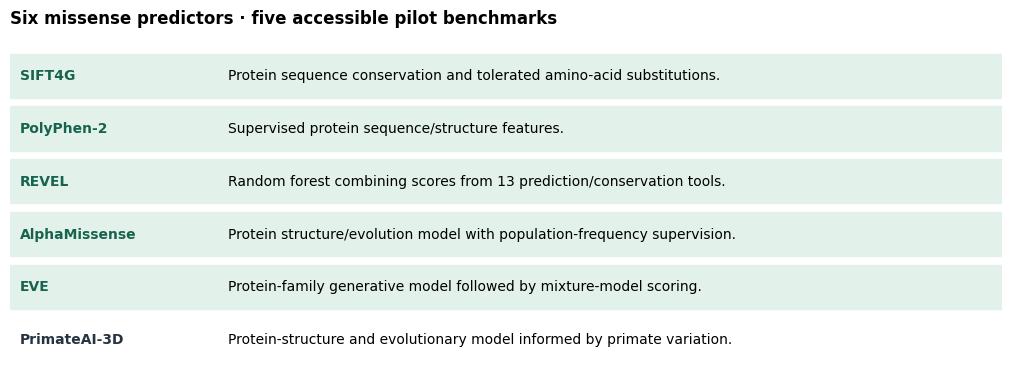

Tool,Release,Method,Variants,Inputs,Access,Compute,License,Sources
SIFT4G,2016 method; dbNSFP4.9a SIFT4G_score field for this benchmark,Protein sequence conservation and tolerated amino-acid substitutions.,Missense substitutions; transcript/protein mapping is required for genomic SNVs.,Exact GRCh38 alleles for published-score lookup; protein queries and homologous sequences for new scoring.,Public local implementation; annotation databases must match the selected species and reference. Q8 retrieves exact GRCh38 allele scores from the public indexed GRR dbNSFP4.9a distribution.,CPU supported; optional CUDA acceleration for database construction/scoring.,Implementation: GPL-3.0; external sequence database terms are separate. The benchmark uses the academic dbNSFP4.9a branch with upstream restrictions.,"SIFT4G — source, protein inputs and compute · SIFT4G — GPL-3.0 license · Vaser et al. — SIFT missense predictions for genomes (2016) · GRR — indexed GRCh38 dbNSFP4.9a release, preparation and checksums · dbNSFP4.9a — score definitions, directions and transcript mappings"
PolyPhen-2,"2.2.3 method; HumVar model, dbNSFP4.9a Polyphen2_HVAR_score field",Supervised protein sequence/structure features.,Missense substitutions in supported proteins.,"Protein accession, residue position and amino-acid substitution; genomic mapping is also available.","Web interface, standalone software and precomputed annotations. Q8 retrieves exact GRCh38 allele scores from the public indexed GRR dbNSFP4.9a distribution.",CPU lookup or local scoring with protein/structure databases.,Academic instruction/research use; other use requires the authors' commercial license. The benchmark uses the academic dbNSFP4.9a branch with upstream restrictions.,"PolyPhen-2 — release 2.2.3r408 and usage terms · PolyPhen-2 — HumDiv and HumVar training data · Adzhubei et al. — PolyPhen-2 protocol (2013) · GRR — indexed GRCh38 dbNSFP4.9a release, preparation and checksums · dbNSFP4.9a — score definitions, directions and transcript mappings"
REVEL,2016 model; pinned v1.3 score export dated 2021-05-03 (Zenodo 7072866),Random forest combining scores from 13 prediction/conservation tools.,Missense SNVs with valid protein/transcript mappings.,Genomic alleles plus transcript/amino-acid mapping; some lifted GRCh38 positions are missing.,Precomputed v1.3 scores at Zenodo record 7072866; downloaded and evaluated by Q8.,CPU lookup; relatively little work after downloading and indexing scores.,Scores: non-commercial use; contact authors for other uses.,"REVEL — method and training overview · REVEL — 2021 score export, GRCh38 mapping and terms · Rothstein and Sieh — REVEL v1.3 score release and checksums"
AlphaMissense,2023 prediction release; code reference pinned,Protein structure/evolution model with population-frequency supervision.,Human missense substitutions in the released transcript/protein catalog.,Exact GRCh38 alleles for this benchmark; retain transcript/protein annotations from the published score file.,Public precomputed predictions and reference code; trained weights are not provided.,CPU lookup of the score release; new inference cannot be reproduced from the published code alone.,Code: Apache-2.0. Later official README: predictions CC BY 4.0; pinned 2023 archive header: CC BY-NC-SA 4.0. Both statements are retained in provenance.,"AlphaMissense — score availability, missing weights and licenses · DeepMind — AlphaMissense training and predictions · Cheng et al. — AlphaMissense (2023) · EMBL-EBI — AlphaMissense score calibration and thresholds · DeepMind AlphaMissense — pinned hg38 score archive metadata"
EVE,2021 method; dbNSFP4.9a EVE_score field for this benchmark,Protein-family generative model followed by mixture-model scoring.,Missense substitutions for proteins and positions covered by the released models.,Protein/residue mapping for lookup; a protein-family MSA for new model fitting.,Public score browser/downloads and code for rebuilding models. Q8 retrieves exact G

Tool,Training,Clinvar,Caution,Sources
SIFT4G,Evolutionary protein sequence alignments; no clinical-label fitting in the core scoring method.,This review does not establish independence of every distributed database or later benchmark.,A protein-impact score is not a calibrated disease probability; missing mappings and alignments limit applicability. Q8 orients raw scores as 1 - score and takes the maximum over matches.,"SIFT4G — source, protein inputs and compute · SIFT4G — GPL-3.0 license · Vaser et al. — SIFT missense predictions for genomes (2016) · GRR — indexed GRCh38 dbNSFP4.9a release, preparation and checksums · dbNSFP4.9a — score definitions, directions and transcript mappings"
PolyPhen-2,HumDiv/HumVar include known disease/function variants and neutral comparators.,Disease variants can recur in ClinVar even though the original training sources were different.,"Audit the exact model and training overlap; useful as a historical comparator, not an assumed independent reference. HumVar was selected before evaluating the pilot; use the maximum matching raw score.","PolyPhen-2 — release 2.2.3r408 and usage terms · PolyPhen-2 — HumDiv and HumVar training data · Adzhubei et al. — PolyPhen-2 protocol (2013) · GRR — indexed GRCh38 dbNSFP4.9a release, preparation and checksums · dbNSFP4.9a — score definitions, directions and transcript mappings"
REVEL,HGMD disease variants and rare neutral variants; constituents bring their own training histories.,ClinVar was a published evaluation set; overlapping variants and inherited labels remain concerns.,Use only with an explicit overlap audit and report mapping failures rather than treating absent scores as benign.,"REVEL — method and training overview · REVEL — 2021 score export, GRCh38 mapping and terms · Rothstein and Sieh — REVEL v1.3 score release and checksums"
AlphaMissense,Human/primate population-frequency labels; core model is not fitted directly to ClinVar classifications.,Released scores are calibrated and category thresholds selected using ClinVar; clinical benchmarking is also reported.,Use continuous scores and audit calibration membership; do not describe this as wholly ClinVar-independent.,"AlphaMissense — score availability, missing weights and licenses · DeepMind — AlphaMissense training and predictions · Cheng et al. — AlphaMissense (2023) · EMBL-EBI — AlphaMissense score calibration and thresholds · DeepMind AlphaMissense — pinned hg38 score archive metadata"
EVE,Evolutionary MSAs; the core workflow requires no clinical labels.,"ClinVar labels are supplied for evaluation, separate from MSA model fitting.",Coverage and homologous-sequence exposure still matter; external clinical calibration would need a separate audit. Q8 uses continuous scores without category or uncertainty filtering.,"EVE — MSA training, score downloads, ClinVar evaluation and MIT license · GRR — indexed GRCh38 dbNSFP4.9a release, preparation and checksums · dbNSFP4.9a — score definitions, directions and transcript mappings"
PrimateAI-3D,Common human/primate variation with structural and evolutionary learning objectives.,The authors report clinical benchmarking without relying on clinical annotations for core training.,Exact population and protein overlap are not audited here; availability is gated by the score agreement.,"PrimateAI-3D — score access, academic agreement and PyTorch implementation · Illumina research team — PrimateAI-3D training and scope"


In [2]:
q8.show_landscape(survey)
q8.show_comparison(survey)

## Selected reference: AlphaMissense

The [official release](https://github.com/google-deepmind/alphamissense/blob/fe2dc845f93310abd6c1b0e8955d7a96c2144d66/README.md) supplies precomputed human missense scores; trained weights are unavailable. Direct GRCh38 lookup avoids additional protein annotation infrastructure. Selection reflects practical access, not a claim that AlphaMissense outperforms the other surveyed tools.

The released scores and classification thresholds use ClinVar calibration ([calibration explanation](https://www.ebi.ac.uk/training/online/courses/alphafold/classifying-the-effects-of-missense-variants-using-alphamissense/understanding-pathogenicity-scores-from-alphamissense/)). Exact calibration membership is unresolved, so these scores cannot serve as independent biological ground truth. We use continuous scores and retain the original ClinVar outcomes. The archive header says CC BY-NC-SA 4.0 while the later official README says CC BY 4.0; provenance records both statements.

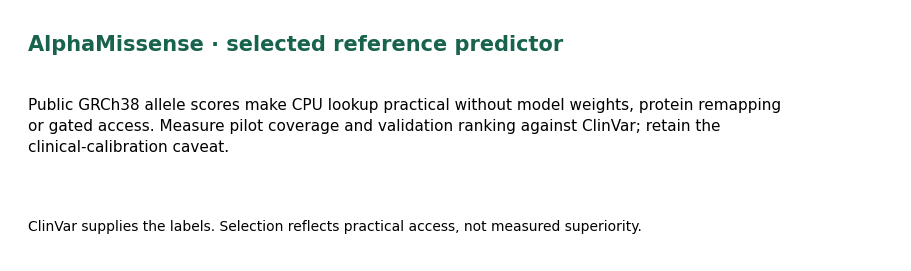

Survey checks passed; catalog, comparisons, figures and provenance saved to results/q8/.


In [3]:
q8.show_shortlist(survey)
q8.export_results(survey)

## Reproducible setup and pilot evaluation

The following call verifies Q1 file checksums and reruns its full-cohort, missense and sequence leakage audits. It freezes the lookup/evaluation settings before reading outcomes, downloads the pinned AlphaMissense hg38 generation when absent, and verifies the archive's published MD5. Partial or corrupt downloads fail before use.

**Matching:** exact GRCh38 chromosome, 1-based position, REF and ALT, removing only the `chr` prefix. No liftover or reverse complementation. For multiple matching transcript annotations, use the **maximum continuous score**, fixed independently of labels. Save every matched annotation, transcript count, minimum score and score range. Unmatched alleles remain unscored.

**Evaluation:** score both partitions; load ClinVar outcomes only after lookup. Report coverage by split and class, then validation AUROC and average precision on covered variants. Percentile 95% intervals use 1,000 bootstrap samples of Q1 components with seed 42; all members are resampled together before restricting to covered variants. One-class replicates are skipped and counted. No threshold tuning, recalibration or Q2 retraining occurs.

`clinvar-test-pilot.vcf` is **validation**, not an independent test. Q1 checks certify the local split, not independence from AlphaMissense's external protein/evolutionary inputs or clinical calibration.

Reusing verified AlphaMissense archive.


  Read 20,000,000 score rows; retained 1,327 annotations.


  Read 40,000,000 score rows; retained 2,677 annotations.


  Read 60,000,000 score rows; retained 3,922 annotations.


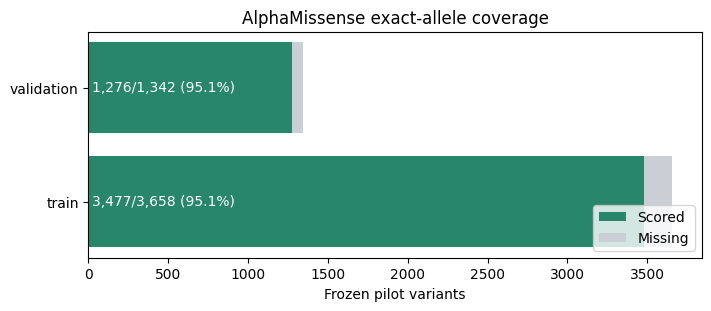

split,class,total,covered,missing,coverage_fraction
train,all,3658,3477,181,0.950519
train,benign,2213,2088,125,0.943516
train,pathogenic,1445,1389,56,0.961246
validation,all,1342,1276,66,0.950820
validation,benign,867,829,38,0.956171
validation,pathogenic,475,447,28,0.941053


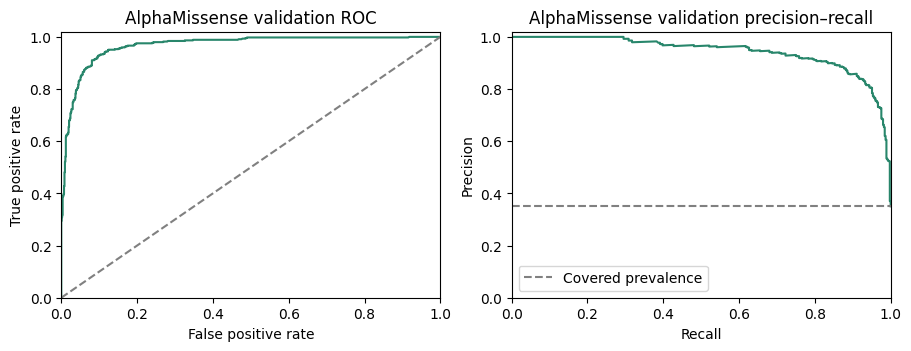

Q1 hashes unchanged; scores, coverage, validation metrics and provenance saved to results/q8/.


In [4]:
report = q8_baseline.run_baseline()

[Scores without labels](results/q8/pilot_scores.csv) · [All matching annotations](results/q8/matched_annotations.csv) · [Coverage](results/q8/coverage.csv) · [Metrics](results/q8/validation_metrics.json) · [Evaluation with ClinVar labels](results/q8/pilot_evaluation.csv)

[Benchmark protocol](results/q8/baseline_protocol.json) · [Benchmark provenance and checks](results/q8/baseline_provenance.json) · [Survey provenance](results/q8/provenance.json) · [Survey comparison](results/q8/tool_comparison.csv)

Generated files and the downloaded archive remain outside Git. The notebook and Python modules reproduce them.

## Additional comparator: REVEL

REVEL is a random forest combining 13 prediction and conservation tools, including SIFT and PolyPhen-2 ([method](https://pmc.ncbi.nlm.nih.gov/articles/PMC5065685/)). Its model and evidence differ from AlphaMissense, and its public scores support reproducible CPU lookup. This choice was made before evaluating the pilot.

Download the pinned **v1.3 release, 3 May 2021**, from [Zenodo record 7072866](https://zenodo.org/records/7072866) into `data/revel/` when absent. Verify its published MD5 and 667,102,707-byte size; stream the zipped CSV without extracting it. The [download page](https://sites.google.com/site/revelgenomics/downloads) specifies non-commercial use; Zenodo separately lists ODC-ODbL. Provenance records both statements.

**Matching:** use exact GRCh38 chromosome, `grch38_pos`, REF and ALT. Skip `.` positions; never fall back to `hg19_pos`. Take the maximum score across matching transcript annotations, independently of labels, and save every match. Unmatched variants remain unscored. Use the same Q1 audits, label loading, coverage reporting, validation metrics and 1,000 component-bootstrap replicates as AlphaMissense.

**Exposure:** REVEL trained on HGMD disease variants and presumed neutral population variants; its constituent tools have additional training histories. Exact overlap with this ClinVar pilot is unresolved. There is no local model fitting, threshold selection or recalibration. [Implementation](src/q8_revel.py).

Reusing verified REVEL archive.


  Read 20,000,000 REVEL rows; retained 1,244 annotations.


  Read 40,000,000 REVEL rows; retained 2,299 annotations.


  Read 60,000,000 REVEL rows; retained 3,547 annotations.


  Read 80,000,000 REVEL rows; retained 4,898 annotations.


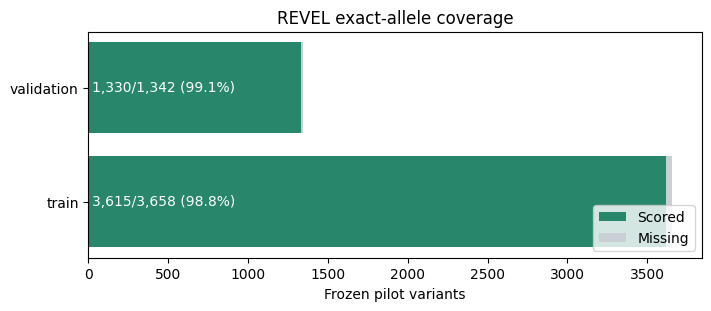

split,class,total,covered,missing,coverage_fraction
train,all,3658,3615,43,0.988245
train,benign,2213,2178,35,0.984184
train,pathogenic,1445,1437,8,0.994464
validation,all,1342,1330,12,0.991058
validation,benign,867,859,8,0.990773
validation,pathogenic,475,471,4,0.991579


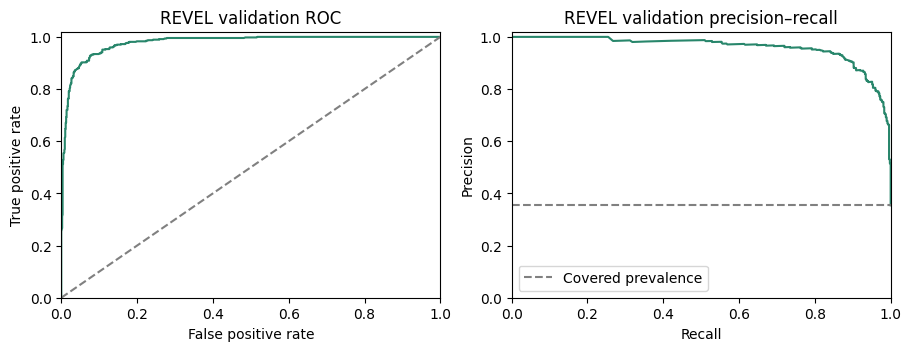

Q1 hashes unchanged; REVEL predictions and evaluation saved to results/q8/revel/.


In [5]:
revel_report = q8_revel.run_baseline()

[REVEL scores without labels](results/q8/revel/pilot_scores.csv) · [All matching annotations](results/q8/revel/matched_annotations.csv) · [Coverage](results/q8/revel/coverage.csv) · [Validation metrics](results/q8/revel/validation_metrics.json) · [Protocol](results/q8/revel/baseline_protocol.json) · [Provenance](results/q8/revel/baseline_provenance.json)

The [README comparison](../README.md#method-comparison) recomputes comparisons on shared scored variants and refreshes when this notebook or its prediction exports change.

## Additional comparators: SIFT4G, PolyPhen-2 and EVE

The public [GRR dbNSFP4.9a release](https://grr.iossifovlab.com/hg38/scores/dbNSFP4.9a/index.html) provides indexed GRCh38 allele scores from the 2024 academic database. [Acquisition code](src/q8_dbnsfp.py) uses the published Tabix index and HTTP byte ranges to avoid downloading the full 39.5 GB file. Metadata MD5s, pinned data ETag/generation, exact byte ranges and BGZF CRCs are verified. Downloaded blocks and the final pilot extraction have checksums; the **full database MD5 is not recomputed**. The first successful extraction is bound to the ordered pilot keys and producing code, then reused offline.

These choices were fixed before outcomes ([score-field definitions](https://grr.iossifovlab.com/hg38/scores/dbNSFP4.9a/dbNSFP4.9a.readme.txt)):

- **SIFT4G:** `1 - SIFT4G_score`, so larger values predict damage.
- **PolyPhen-2:** `Polyphen2_HVAR_score` from **HumVar**; larger values predict damage.
- **EVE:** continuous `EVE_score`; retain all finite scores without confidence-category filtering.

Use the maximum oriented score across exact-allele rows and transcript/protein score entries, preserving raw scores and mapping fields. Missing score entries and absent alleles remain unscored. The extracted input excludes clinical fields; outcomes are joined only for evaluation. The same Q1 audits, fixed splits, coverage reports and component bootstrap apply to all three tools ([implementation](src/q8_remaining.py)). No local fitting or recalibration occurs.

**Exposure:** SIFT4G and EVE use evolutionary sequence information; its overlap is unaudited. PolyPhen-2 HumVar uses known disease variants, whose overlap with ClinVar is unresolved. EVE covers a limited protein/position catalog, so its covered subset can differ substantially. The academic database and upstream tool restrictions apply.

Reusing verified dbNSFP pilot score extraction offline.


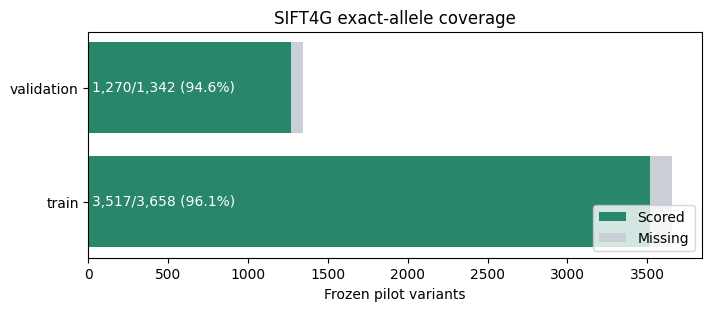

split,class,total,covered,missing,coverage_fraction
train,all,3658,3517,141,0.961454
train,benign,2213,2105,108,0.951197
train,pathogenic,1445,1412,33,0.977163
validation,all,1342,1270,72,0.946349
validation,benign,867,811,56,0.935409
validation,pathogenic,475,459,16,0.966316


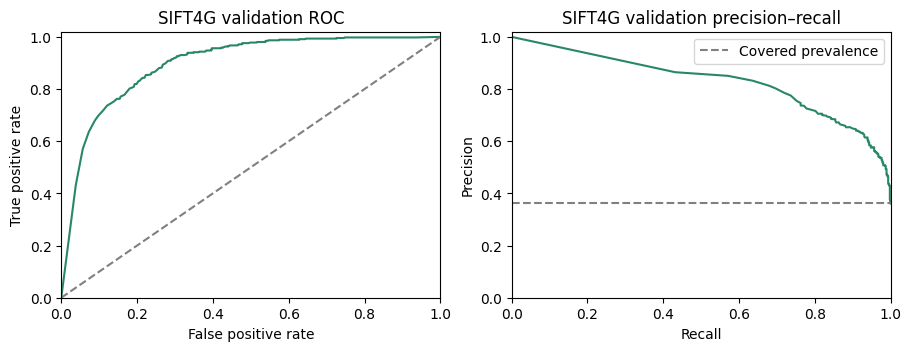

SIFT4G: 1270/1342 validation variants scored.


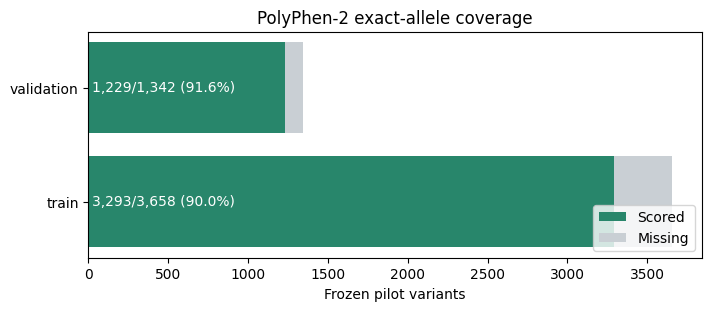

split,class,total,covered,missing,coverage_fraction
train,all,3658,3293,365,0.900219
train,benign,2213,1960,253,0.885676
train,pathogenic,1445,1333,112,0.922491
validation,all,1342,1229,113,0.915797
validation,benign,867,770,97,0.888120
validation,pathogenic,475,459,16,0.966316


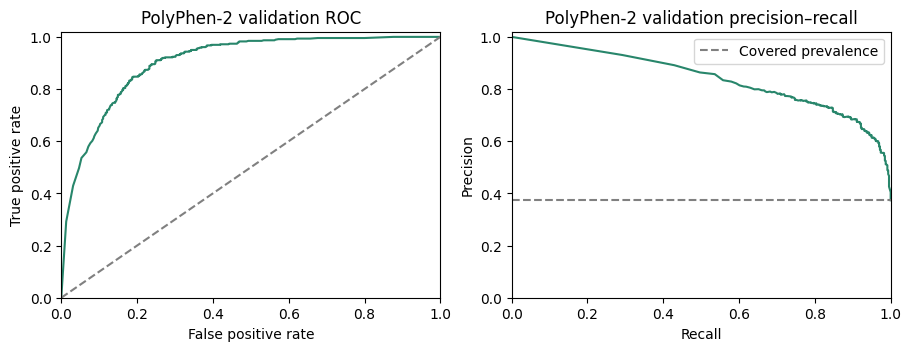

PolyPhen-2: 1229/1342 validation variants scored.


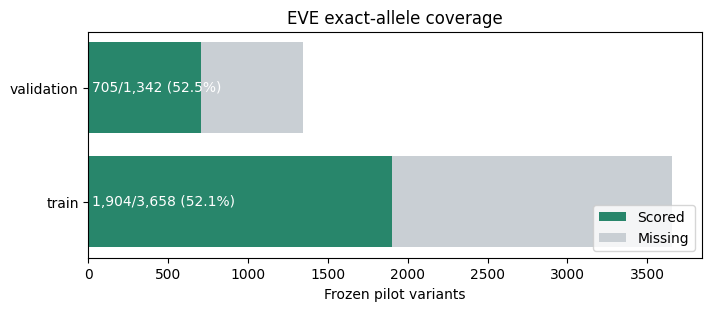

split,class,total,covered,missing,coverage_fraction
train,all,3658,1904,1754,0.520503
train,benign,2213,825,1388,0.372797
train,pathogenic,1445,1079,366,0.746713
validation,all,1342,705,637,0.525335
validation,benign,867,345,522,0.397924
validation,pathogenic,475,360,115,0.757895


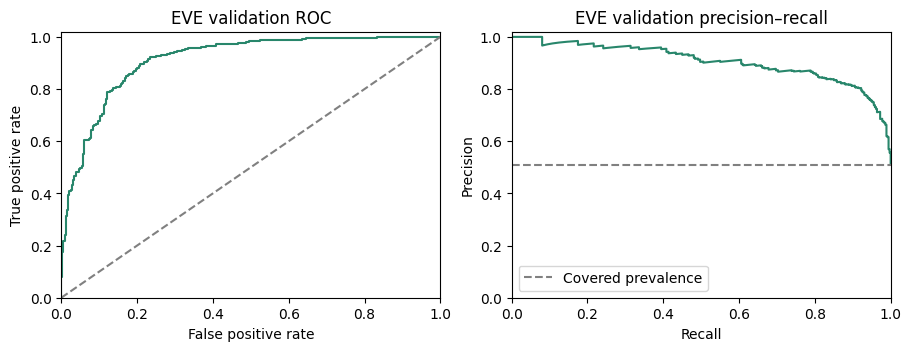

EVE: 705/1342 validation variants scored.


In [6]:
remaining_reports = q8_remaining.run_baselines()

[SIFT4G results](results/q8/sift4g/) · [PolyPhen-2 HumVar results](results/q8/polyphen2/) · [EVE results](results/q8/eve/)

Each folder contains scores without labels, matched annotations, split/class coverage, validation metrics, plots, a frozen protocol and completion provenance. See [artifact descriptions](results/README.md#q8-artifacts-missense-survey-and-external-predictors).

## PrimateAI-3D: licensed data required

The [official repository](https://github.com/Illumina/PrimateAI-3D/blob/a3c210bcd0880c72b307b5fba0a2a17bddda59cd/README.md) requires a signed license agreement and supplies its score/model download link by email. No approved download link or licensed local score file was available for this run. The following cell records that access result; it does not produce predictions or metrics. dbNSFP's original **PrimateAI** scores belong to a different model and cannot represent PrimateAI-3D.

In [7]:
primate_access = q8_remaining.report_primate_access()

**PrimateAI-3D: access blocked.** PrimateAI-3D has not been run: Illumina requires a signed license agreement and supplies the score/model download link by email. No approved link or licensed score file was provided. The original PrimateAI scores in dbNSFP are a different model and are not substituted. [Official access instructions](https://github.com/Illumina/PrimateAI-3D/tree/a3c210bcd0880c72b307b5fba0a2a17bddda59cd).

## Conclusion

In [8]:
q8_remaining.show_conclusion(report, revel_report, remaining_reports, primate_access)

| Method | Scored / validation | AUROC [95% CI] | Average precision [95% CI] |
| --- | --- | --- | --- |
| AlphaMissense | 1,276 / 1,342 | 0.967 [0.958, 0.976] | 0.943 [0.922, 0.960] |
| REVEL | 1,330 / 1,342 | 0.978 [0.970, 0.985] | 0.960 [0.941, 0.975] |
| SIFT4G | 1,270 / 1,342 | 0.897 [0.877, 0.915] | 0.798 [0.748, 0.840] |
| PolyPhen-2 | 1,229 / 1,342 | 0.903 [0.884, 0.921] | 0.827 [0.775, 0.872] |
| EVE | 705 / 1,342 | 0.912 [0.888, 0.934] | 0.906 [0.869, 0.937] |

Five predictors have reproducible pilot scores; PrimateAI-3D remains blocked on licensed data access. **ClinVar remains the reference labels.** Metrics above use each method’s scored validation subset; the [README comparison](../README.md#method-comparison) recomputes metrics on the common scored subset. Coverage is a separate limitation. Intervals resample Q1 components, and external training/calibration overlap remains unaudited. These are development results.